# Chapter 6. Ensemble Learning and Random Forests

We will often use ensemble methods near the end of a project, once we have already built a few good predictors, to combine them into even better predictor.

In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_moons, load_iris
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingRegressor, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder

# 1. Voting Classifiers

***Hard voting classifier***: the class that gets the most votes is the ensemble's prediction.
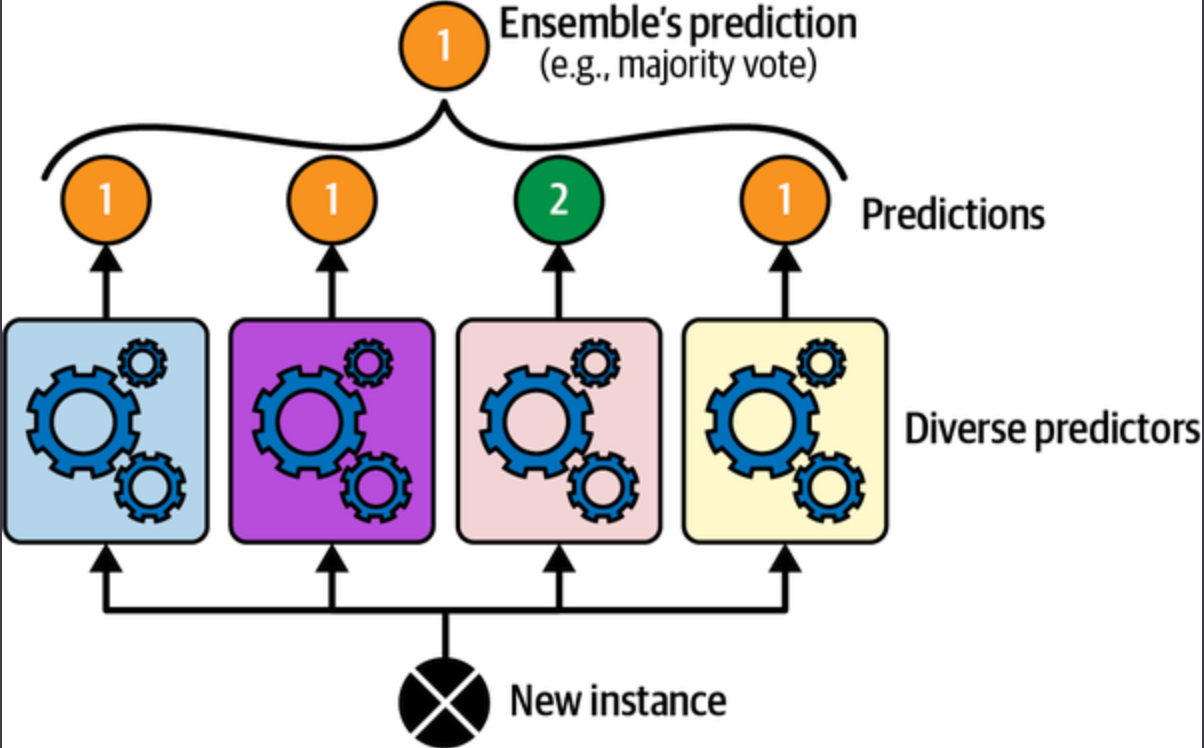

Ensemble methods work best when the predictors are as **independent** from one another as possible. One way to get diverse classifiers is to train them using very different algorithms. This increases the chance that they will make very different types of errors, improving the emsemble's accuracy. We can also tune hyperparameters to get diverse models, or train the models on different subsets of the data.

In [5]:
X, y = make_moons(n_samples=500, noise=0.3, random_state=32)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=32)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=32)),
        ('rf', RandomForestClassifier(random_state=32)),
        ('svc', SVC(random_state=32))
    ]
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=32)),
                             ('rf', RandomForestClassifier(random_state=32)),
                             ('svc', SVC(random_state=32))])

In [3]:
for name, clf in voting_clf.named_estimators_.items():
    print(f'The {name} classifier has an accuracy of {clf.score(X_test, y_test)}')
# 'dir()' can be used to show all attributes of an object (e.g., voting_clf)
print(f'The ensemble classifier has an accuracy of {voting_clf.score(X_test, y_test)}')

The lr classifier has an accuracy of 0.88
The rf classifier has an accuracy of 0.928
The svc classifier has an accuracy of 0.92
The ensemble classifier has an accuracy of 0.928


In [4]:
voting_clf.predict(X_test[[4]])

array([1])

In [5]:
[clf.predict(X_test[[4]]) for clf in voting_clf.named_estimators_.values()]

[array([0]), array([1]), array([1])]

***Soft voting***: If all classifiers can estimate class probabilities, it is prefer to predict the class with the **highest class probability, averaged over all the individual classifiers**. It often achieves higher performance than hard voting because it gives more weight to highly confident votes.

In [6]:
voting_clf_soft = VotingClassifier(
    estimators = [
        ('lr', LogisticRegression(random_state=32)),
        ('rf', RandomForestClassifier(random_state=32)),
        ('svc', SVC(random_state=32, probability=True))
    ]
)
voting_clf_soft.fit(X_train, y_train)
voting_clf_soft.score(X_test, y_test)

0.928

## 2. Bagging and Pasting

Another way to get diverse classifiers is to use the **same training algorithm** for every predictor but train them on **different random subsets of the training set**.
- When sampling is performed **with replacement** -> ***Bagging***
    - Prefer bagging when dataset is noisy / model is prone to overfitting, because bagging would introduce more diversity, though this ends up with a slighly higher bias than pasting; but the extra diversity also let the predictors being less correlated, so the emsemble's variance is reduced. Overall, **bagging often results in better models**.
    -  In practice, bagging is used far more often than pasting because bagging offers ***out-of-bag (OOB) evaluation***. Because sampling is done with replacement, on average about 37% of the training instances are never drawn into a given subset. These OOB instances serve as a ready-made validation set for the predictor trained on that subset, so you can estimate generalization performance without setting aside a seperate validation set. Pasting cannot offer this.
        - Where the 37% comes from: the probability that a particular instance (training set size: m) is never picked across n draws with replacement is (1−1/m)**n (sciket-learn default: m=n), when m (and n) increase, it approaches e**(-1) ~= 0.368.
- When sampling is performed **without replacement** -> ***Pasting***
    - Pasting avoids redundancy (because every sample possess 'new information'ZQ) and has a bit more computationally efficient.

In practice, the ensemble often ends up with a similar bias but **a lower variance** than a single predictor trained on the original training set. So it works best with high-variance and low-bias models (e.g., ensemble of decision trees, not ensemble of linear regressors).

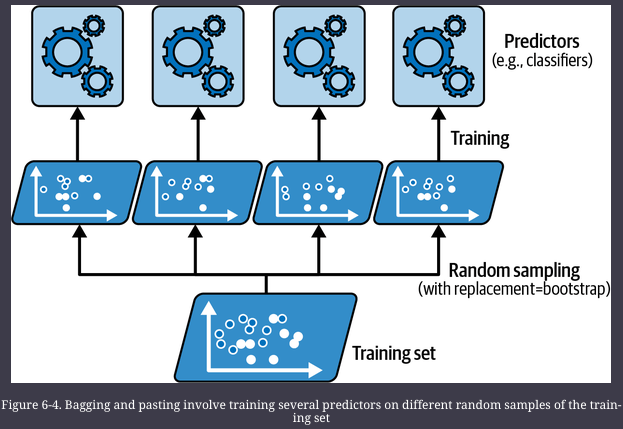

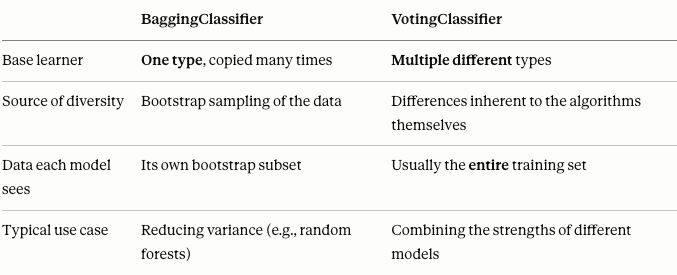

### 2.1. Bagging and Pasting in Scikit-Learn

In [7]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=1.0, random_state=32)
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=500,
                  random_state=32)

A `BaggingClassifier` automatically performs soft voting instead of hard voting if the base classifier can estimate class probabilities (e.g., decision tree classifier).

### 2.2. Out-of-Bag Evaluation

In [8]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=1.0, random_state=32, 
                            oob_score=True) # OOB score parameter
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.8906666666666667

In [9]:
bag_clf.score(X_test, y_test)

0.936

### 2.3. Random Patches and Random Subspaces

`BaggingClassifier` supports sampling **features** as well, which is useful for high-dimensional inputs (such as images). 
- `max_features`
- `bootstrap-features`
<br>

**Sampling features introduces even more predictor diversity**, trading a bit more bias for a lower variance.
<br>

***Random patches method***: sampling both training instances and features.
<br>

***Random subspaces method***: keeping all training instances but sampling features.

## 3. Random Forests

A ***random forest (RF)*** is an ensemble of **decision trees**, typically trained via **bagging**. Unlike the general `BaggingClassifier`, RF adds extra randomness: at each split, it searches for the best feature among a **random subset** of features rather than all features (this is the source of the word *"Random"*).
- Note: `RandomForestClassifier` has **no `estimator` parameter** — the base learner has been set as decision trees by design. If you want bagging with a different base learner, use `BaggingClassifier(estimator=...)` instead.

In [10]:
rf_clf = RandomForestClassifier(n_estimators=500, random_state=32)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

The `RandomForestClassifier` automatically introduces extra randomness through search for the best feature among **a random subset (sqrt(n)) of features** (where n is the total number of features), which trades a higher bias for a lower variance.

### 3.1. Extra-Trees

***Extremely randomized trees***: We can make trees even more random by using **random thresholds for each feature** instead of searching for the best possible threshoulds by using `ExtraTreesClassifier` class. -> trade more bias for lower variance.

### 3.2. Feature Importance

Scikit-Learn measures a feature's importance by looking at how much the tree nodes that use that feature reduce impurity on average, across all trees in the forest -> it is a weighted average, where each node's weight is equal to the number of training samples that are associated with it.
- Scikit-Learn compute and scale the score for each feature, so that the **sum of all importance = 1**

In [11]:
iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=32)
rnd_clf.fit(iris.data, iris.target)

iris_feature_importance = pd.DataFrame({
    'feature': iris.data.columns,
    'importance': rnd_clf.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)
iris_feature_importance

,feature,importance
0,petal width (cm),0.465089
1,petal length (cm),0.413417
2,sepal length (cm),0.098797
3,sepal width (cm),0.022698


## 4. Boosting

***Boosting*** refers to any ensemble method that can combine several weak learners into a strong learner. The general idea of most boosting methods is to **train predictor sequentially, each trying to correct its predecessor**. The most popular two are ***Adaboost (adaptive boosting)*** and ***gradient boosting***.
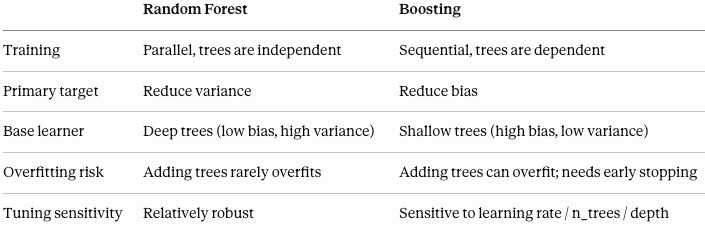

### 4.1. AdaBoost

***AdaBoost***: A new predictor correct its predecessor by paying more attention to the training instances that the predecessor underfit (e.g., through increasing the relative weight of missclassified training instances before fitting the next predictor) -> new predictors focusing more and more on the hard cases.
- Drawback: training cannot be parallelized so it does not scale well as bagging/pasting.

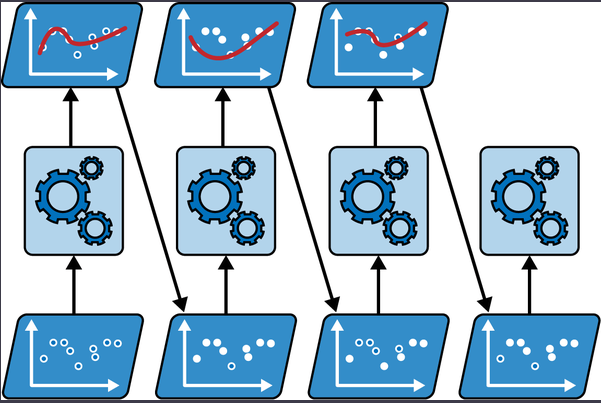

Once all predictors are trained, the ensemble makes predictions similar to bagging/pasting, except that predictions have different weights depending on their overall accuracy on the weighted training set.
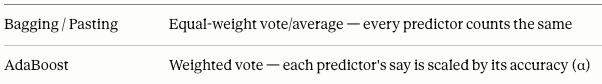

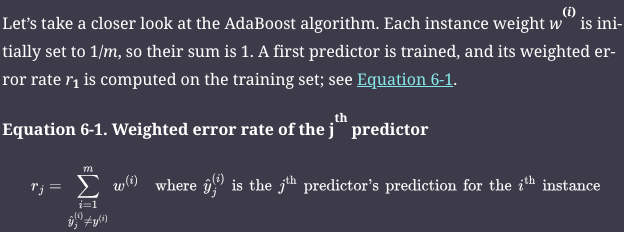
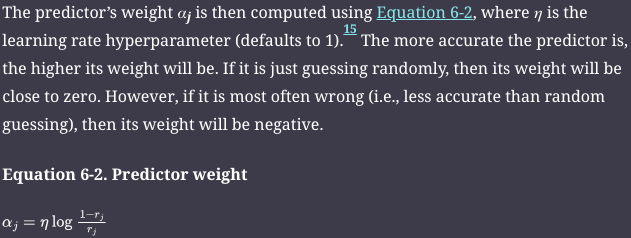
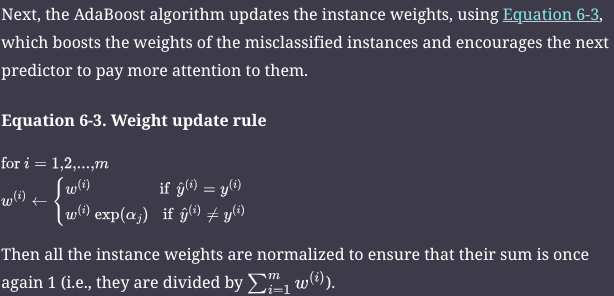
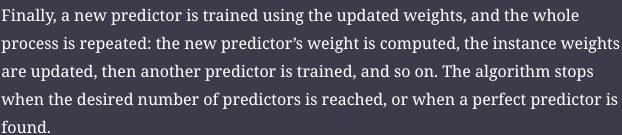
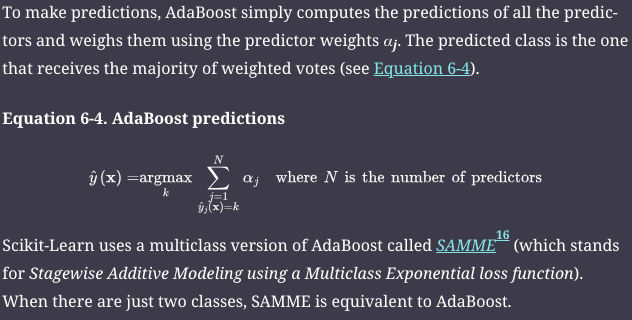

In [12]:
ada_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=2), 
                             n_estimators = 50, learning_rate=0.5, 
                             random_state=32, algorithm='SAMME')
ada_clf.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=2),
                   learning_rate=0.5, random_state=32)

If our AdaBoost ensemble is overfitting the training set, we can try reducing the number of estimators or more strongly regularizing the base estimator.

### 4.2. Gradient Boosting

***Gradient boosting*** works similarly to AdaBoost. However, instead of tweaking the instance weights at every iteration, it fits the new predictor to the **negative gradient of the loss function** (a.k.a. the *pseudo-residual*) made by the previous ensemble.

The final prediction is the **sum of all trees**, scaled by the learning rate $\eta$:

$$F(\mathbf{x}) = F_0 + \eta \sum_{m=1}^{M} h_m(\mathbf{x})$$

- For **regression**, this sum *is* the prediction directly (in the units of $y$).
- For **classification**, this sum lives in **log-odds space**; a **sigmoid** (binary) or **softmax** (multiclass) then maps it to a probability.

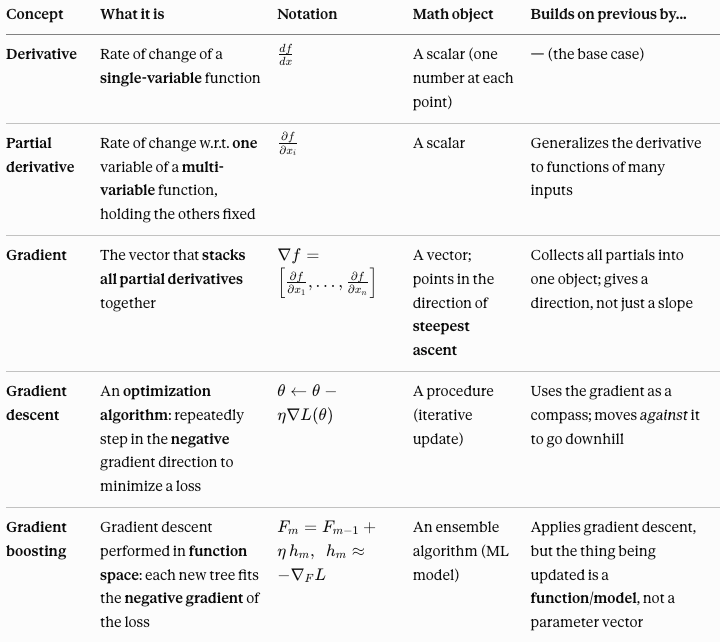

In [13]:
gb_clf = GradientBoostingClassifier(random_state=32, 
                                    n_estimators=500,
                                    learning_rate=0.05,
                                    n_iter_no_change=10, # early stopping
                                    subsample=0.25)

***Shrinkage***: the `learning_rate` hyperparameter scales the contribution of each tree. **low learning rate** (e.g., 0.05) -> requires more trees in the ensemble to fit the training set -> but the predictions will usually **generalize better**.
- ***Early stopping***: To find the optimal number of trees (= `n_estimators`) automatically,
  set `n_estimators` to a large upper bound and `n_iter_no_change = n`. Training will
  stop early once the validation score hasn't improved for `n` consecutive trees.
  This avoids manually tuning `n_estimators` via grid search.
<br>

***Stochastic Gradient Boosting***: the `subsample` hyperparameter sets the fraction of training instances used to train each tree (e.g., `subsample=0.25` -> each tree trains on a random 25% of the data). This trades **higher bias for lower variance**, and **speeds up training** considerably.


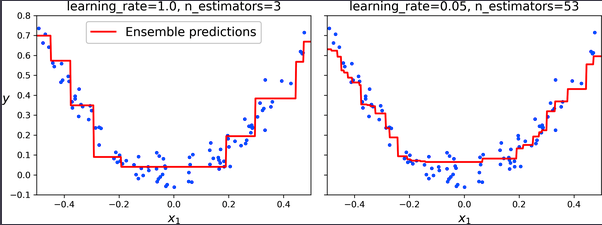

### 4.3. Histogram-Based Gradient Boosting

***Histogram-based gradient boosting (HGB)*** works by binning the input features and replacing them with integers (`max_bins` hyperparameter). **Binning greatly reduces the number of possible thresholds that the training algorithm needs to evaluate.**
- HGB can train hundreds of times faster than regular GBRT on large datasets. 
- HGB cause precision loss, acting as a regularizer -> may reduce overfitting or cause underfitting.
- Scikit-Learn provides `HistGradientBoostingRegressor` and `HistGradientBoostingClassifier`.
- HGB supports **missing value** natively and **categorical features(one hot encoding)**.

In [17]:
hgb_reg = make_pipeline(
    make_column_transformer((OrdinalEncoder(), ["ocean_proximity"]),
                            remainder="passthrough",
                            force_int_remainder_cols=False),
    HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
)

## 5. Stacking

Instead of a trivial aggregation function (e.g., hard voting / averaging), **stacking** trains a model — the *blender* / meta-learner — to combine the base predictors' outputs. 
- To train the blender, we need to build the blending training set. We can use `cross_val_predict()` on every predictor in the ensemble to get out-of-sample predictions for each instance in the original dataset, and use these as the input features to train the blender; the target can simply be copied from the original training set.
- Regardless of the number of features in the original training set, the blending training set will contain one input feature per predictor.
- Once the blender is trained, the base predictors must be retrained one last time on the full original training set (because `cross_val_predict()` does not give access to the trained estimators). 
<br>
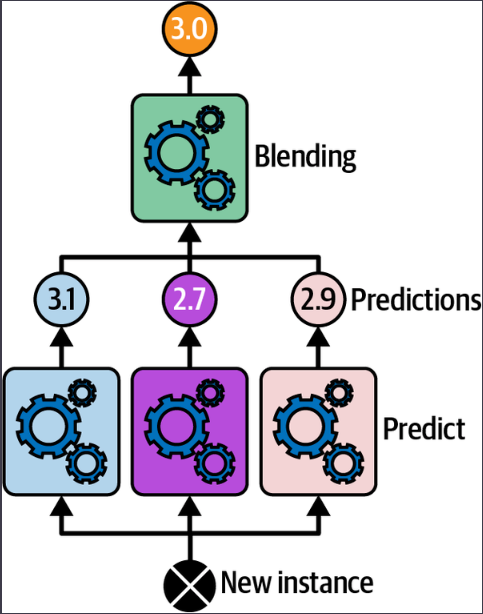
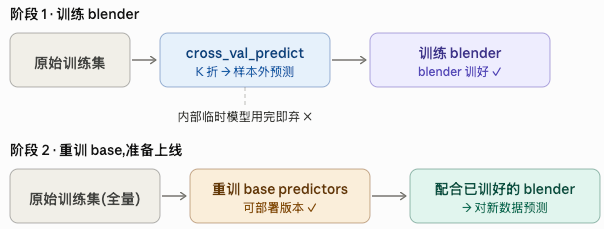
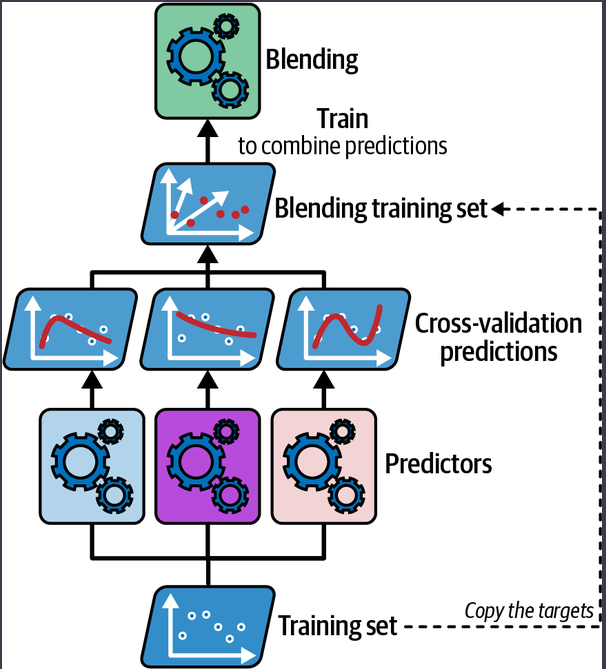

It is possible to train several different blenders this way to get a whole layer of blenders (e.g., one using linear regression, one using RF regression), and then add another blender on top of that to produce the final predictions. We may be able to squeeze out a few more drops of performance by doing this, but it will cost you in both training time and system complexity.
<br>

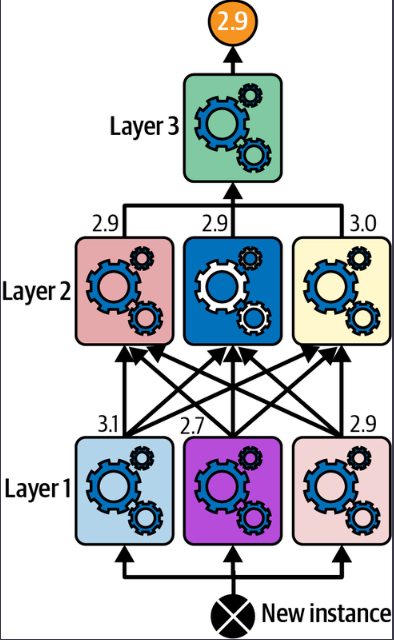

In [6]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=32)),
        ('rf', RandomForestClassifier(random_state=32)),
        ('svc', SVC(probability=True, random_state=32))
    ],
    final_estimator=RandomForestClassifier(random_state=32),
    cv=5  # number of cross-validation folds
)
stacking_clf.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression(random_state=32)),
                               ('rf', RandomForestClassifier(random_state=32)),
                               ('svc', SVC(probability=True, random_state=32))],
                   final_estimator=RandomForestClassifier(random_state=32))

| Method | When to use | Example use cases |
|---|---|---|
| **Hard voting** | Balanced classification with several strong, diverse classifiers | Spam detection, sentiment analysis, disease classification |
| **Soft voting** | Classification where confidence / probability scores matter | Medical diagnosis, credit risk analysis, fake news detection |
| **Bagging** | Structured / semi-structured data with high-variance, overfit-prone models | Financial risk modeling, e-commerce recommendation |
| **Pasting** | Structured / semi-structured data needing more independent models | Customer segmentation, protein classification |
| **Random forest** | High-dimensional structured data with noisy features | Customer churn prediction, genetic data analysis, fraud detection |
| **Extra-trees** | Large structured data, many features; speed-critical + extra variance reduction | Real-time fraud detection, sensor data analysis |
| **AdaBoost** | Small-to-medium, low-noise structured data with weak learners (e.g., stumps); interpretability helps | Credit scoring, anomaly detection, predictive maintenance |
| **Gradient boosting** | Medium-to-large structured data needing high predictive power (tuning OK) | Housing price prediction, risk assessment, demand forecasting |
| **HGB** | Large structured data where training speed & scalability are key | Click-through rate prediction, ranking, real-time ad bidding |
| **Stacking** | Complex, high-dimensional data where combining diverse models maximizes accuracy | Recommendation engines, autonomous-vehicle decisions, Kaggle |

**Random forests, AdaBoost, Gradient boosting, and HGB are among the first models you should test for most machine learning tasks**, particularly with heterogeneous tabular data. Moreover, as they require very little preprocessing, they’re great for getting a prototype up and running quickly.